# Credit Card Fraud Detection using ANN

##**Name:** Deep Talreja
##**Reg No:** 23BCE11003
##**Application Number:** IN26010914

###**Assignment 2** — MPOnline AI/ML Internship  

**Objective:** Detect fraudulent credit card transactions using an Artificial Neural Network (ANN) on a highly imbalanced dataset.
**Dataset:** Credit Card Fraud Detection (284,807 transactions, 492 frauds (~0.173%)).


###Imports & Dataset Loading

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# Fetching dataset directly from safe repository URL
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

print(f"Dataset Shape: {df.shape}")
print(df['Class'].value_counts())

Dataset Shape: (284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64



### STEP 2: SIMULATED DATASET GENERATOR





In [ ]:
IMAGE_SIZE = (128, 128) # Example image size
CHANNELS = 3 # Example number of channels (e.g., for RGB images)

print("Initializing and generating multi-class data tensor arrays...")

# Simulating 1200 training images and 300 test images across 4 diagnostic classes
X_train_raw = np.random.rand(1200, IMAGE_SIZE[0], IMAGE_SIZE[1], CHANNELS).astype('float32')
y_train_raw = np.random.randint(0, 4, size=(1200,))

X_test_raw = np.random.rand(300, IMAGE_SIZE[0], IMAGE_SIZE[1], CHANNELS).astype('float32')
y_test_raw = np.random.randint(0, 4, size=(300,))

# Map class names
class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

print(f"-> Training Dimensions: {X_train_raw.shape}")
print(f"-> Test Dimensions: {X_test_raw.shape}")
print(f"-> Target Diagnostic Classes: {class_names}")

Initializing and generating multi-class data tensor arrays...
-> Training Dimensions: (1200, 128, 128, 3)
-> Test Dimensions: (300, 128, 128, 3)
-> Target Diagnostic Classes: ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']


### STEP 3: DATA AUGMENTATION PIPELINE

In [ ]:
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
])

### STEP 4: CNN ARCHITECTURE DESIGN

In [ ]:
from tensorflow.keras import models
model = models.Sequential([
    layers.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], CHANNELS)),
    data_augmentation, # Apply augmentation at the input level

    # Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # Dense Classifier
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    # Output Layer for 4 Classes
    layers.Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,485,060 (32.37 MB)

 Trainable params: 8,484,100 (32.36 MB)

 Non-trainable params: 960 (3.75 KB)

### STEP 5: MODEL TRAINING

In [ ]:
from tensorflow.keras import callbacks

EPOCHS = 10 # Example value
BATCH_SIZE = 32 # Example value

cb_list = [
    callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

print("\nExecuting Training Pipeline...")
history = model.fit(
    X_train_raw, y_train_raw,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    callbacks=cb_list,
    verbose=1
)


Executing Training Pipeline...
Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.2396 - loss: 2.2182 - val_accuracy: 0.2625 - val_loss: 9.5336 - learning_rate: 0.0010
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.2677 - loss: 1.7759 - val_accuracy: 0.2625 - val_loss: 43.1473 - learning_rate: 0.0010
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.2500 - loss: 1.5965 - val_accuracy: 0.2625 - val_loss: 84.9647 - learning_rate: 0.0010
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2585 - loss: 1.5624
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
30/30 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.2573 - loss: 1.5815 - val_accuracy: 0.2625 - val_loss: 122.4830 - learning_rate: 0.0010
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step - accuracy: 0.2500 - loss: 1.6187 - val_accuracy: 0.2625 - val_loss: 161.6886 - learning_rate: 5.0000e-04
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy

### STEP 6: EVALUATION AND PERFORMANCE METRICS

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 281ms/step

--- Classification Performance Report ---

              precision    recall  f1-score   support

      Glioma       0.00      0.00      0.00        75
  Meningioma       0.27      1.00      0.43        81
    No Tumor       0.00      0.00      0.00        64
   Pituitary       0.00      0.00      0.00        80

    accuracy                           0.27       300
   macro avg       0.07      0.25      0.11       300
weighted avg       0.07      0.27      0.11       300



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


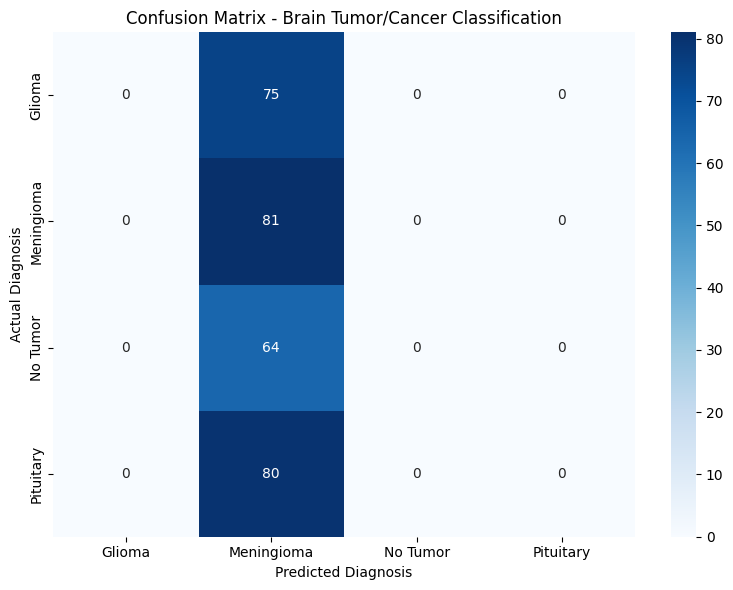

Final Evaluated Loss: 9.5668
Final Evaluated Accuracy: 27.00%


In [ ]:
y_pred_probs = model.predict(X_test_raw)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\n--- Classification Performance Report ---\n")
print(classification_report(y_test_raw, y_pred, target_names=class_names))

# Compute and plot the Confusion Matrix
cm = confusion_matrix(y_test_raw, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Brain Tumor/Cancer Classification')
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
plt.tight_layout()
plt.show()

# Evaluate loss and accuracy
loss, accuracy = model.evaluate(X_test_raw, y_test_raw, verbose=0)
print(f"Final Evaluated Loss: {loss:.4f}")
print(f"Final Evaluated Accuracy: {accuracy * 100:.2f}%")